# PAC-Learning Validation — Model 4: Two-Coupling TFIM

Validates the Fourier Coefficient Extraction pipeline on a strictly harder model than
the standard TFIM: **both** the ZZ coupling and the transverse field are unknown.

$$H(x,\alpha,\beta) = \alpha\sum_{(i,j)\in x}Z_iZ_j + \beta\sum_i X_i$$

| Parameter | Role | TFIM | Model 4 |
|---|---|---|---|
| $\alpha$ | ZZ coupling strength | **known** (= 1, absorbed into $x_{ij}\in\{0,1\}$) | **unknown** |
| $\beta$ | transverse field | unknown | **unknown** |
| d_params | independent unknowns | 1 | **2** |
| Fourier modes | $(4nr+1)$ | 49 (n=3,r=4) | $(4r+1)\times(4nr+1) = 9\times 25 = 225$ (r=2) |

**Why this is a genuine d=2 experiment:** both $\alpha$ (ZZ) and $\beta$ (X)
are encoded into **separate frequency registers** in the A(U) circuit:

- `freq_zz` (for $\alpha$): D·G·D block on each ZZ pair $(i,j)$ — Z parity,
  no basis change needed
- `freq_x` (for $\beta$): D·G·D block on each X qubit — H·CNOT·G·CNOT·H,
  all $n$ qubits shared onto one register

The feature vector is the flattened 2D tensor $b_{l_0,l_1}(x)$ of size
$(4r+1)\times(4nr+1)$, and the Fourier reconstruction is:

$$f(\alpha_\text{up},\beta_\text{up};x) =
\sum_{l_0,l_1} b_{l_0,l_1}(x)\, e^{i\pi\alpha_\text{up}l_0}\, e^{i\pi\beta_\text{up}l_1}$$

**Previous incorrect implementation:** `extract_b_l_full` only encoded $\beta$
(d=1), so the ZZ gates used the hardcoded angle $2\tau/r$ — effectively setting
$\alpha=1$ as prior knowledge in the features. That was a 1D learner disguised
as a 2D one. The new `extract_b_l_model4` encodes both parameters correctly.

**Observables:** $Z_0Z_1$ (balanced sensitivity to both $\alpha$ and $\beta$)
and $Z_0Z_1Z_2$ (highest graph discrimination).


## 1 — Imports & parameters

In [5]:
import sys, os, time
sys.path.append(os.path.abspath('..'))

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.lines import Line2D
from scipy.linalg import expm
from qiskit import QuantumCircuit
from qiskit.quantum_info import Statevector, SparsePauliOp
from sklearn.linear_model import Lasso
import random

from src.quantum_routines import CircuitBuilder

# ── Model 4 parameters ────────────────────────────────────────────────────────
NUM_QUBITS  = 3          # n=3: 8 possible graphs; n=4: 64 possible graphs
TRUE_ALPHA  = 1.0        # ZZ coupling strength (unknown to learner)
TRUE_BETA   = 0.5        # transverse field strength (unknown to learner)
R_STEPS     = 4          # Trotter steps
NUM_TRAIN   = 6          # training graphs (pool size = 2^C(n,2) - 1)
LASSO_ALPHA = 1e-5       # L1 regularisation (small: feature rank is the true constraint)
EPSILON_B   = 0.0        # shot noise (0 = noiseless statevector simulation)

# Observables (Qiskit little-endian: rightmost char = qubit 0)
PAULI_ZZ  = 'I' * (NUM_QUBITS - 2) + 'ZZ'   # Z₀Z₁  e.g. 'IZZ' for n=3
PAULI_ZZZ = 'ZZZ' if NUM_QUBITS == 3 else 'I' * (NUM_QUBITS - 3) + 'ZZZ'

T_VALUES = np.linspace(0, 3, 13)

# ── Graph setup (same pattern as TFIM notebook) ───────────────────────────────
_ALL_EDGES = [(i, j) for i in range(NUM_QUBITS) for j in range(i + 1, NUM_QUBITS)]
ALL_GRAPHS = [
    [_ALL_EDGES[k] for k in range(len(_ALL_EDGES)) if (mask >> k) & 1]
    for mask in range(2 ** len(_ALL_EDGES))
]

# Test graph: fixed before sampling training set (contains edge (0,1) for non-trivial ZZ)
TEST_EDGES   = next(g for g in ALL_GRAPHS if (0, 1) in g)
POOL         = [g for g in ALL_GRAPHS if g != TEST_EDGES]
random.seed(42)
TRAIN_GRAPHS = random.sample(POOL, NUM_TRAIN)

print(f'Model 4:  H = alpha*sum(ZiZj) + beta*sum(Xi)')
print(f'  alpha={TRUE_ALPHA} (ZZ coupling),  beta={TRUE_BETA} (transverse field)')
print(f'  n={NUM_QUBITS},  r={R_STEPS},  {NUM_TRAIN} training graphs')
print(f'  Test graph: {TEST_EDGES}')
print(f'Observables: {PAULI_ZZ}  (Z₀Z₁)   {PAULI_ZZZ}  (Z₀Z₁Z₂)')

Model 4:  H = alpha*sum(ZiZj) + beta*sum(Xi)
  alpha=1.0 (ZZ coupling),  beta=0.5 (transverse field)
  n=3,  r=4,  6 training graphs
  Test graph: [(0, 1)]
Observables: IZZ  (Z₀Z₁)   ZZZ  (Z₀Z₁Z₂)


## 2 — CircuitBuilder & feature extraction

`extract_b_l_model4` builds the full A(U,P) circuit for Model 4 with two
frequency registers — one per unknown parameter:

| Register | Encodes | D·G·D target | Spectrum |
|---|---|---|---|
| `freq_zz` | $\alpha$ (ZZ coupling) | ZZ parity of qubits $i,j$ (no H gates) | $l_0 \in [-2r, +2r]$ |
| `freq_x` | $\beta$ (X field) | X parity of each qubit (with H gates) | $l_1 \in [-2nr, +2nr]$ |

The feature vector is the flattened 2D grid $b_{l_0,l_1}(x)$ of size
$(4r+1)\times(4nr+1)$. The training labels use `compute_au_labels_model4`
which is already correct — it maps both $\alpha$ and $\beta$ to their upload
conventions via $\alpha_\text{up} = \alpha\tau/(\pi r)$,
$\beta_\text{up} = \beta\tau/(\pi r)$.


In [6]:
builder = CircuitBuilder()

OBS_ZZ_MATRIX  = SparsePauliOp(PAULI_ZZ ).to_matrix()
OBS_ZZZ_MATRIX = SparsePauliOp(PAULI_ZZZ).to_matrix()

# 2D feature dimensions for Model 4
SPEC_L0 = 4 * R_STEPS + 1                     # l0 (ZZ/alpha): 4r+1 modes
SPEC_L1 = 4 * NUM_QUBITS * R_STEPS + 1        # l1 (X/beta):   4nr+1 modes
FEATURE_SIZE = SPEC_L0 * SPEC_L1

print(f'Model 4 feature space:')
print(f'  freq_zz (alpha): l0 in [-{2*R_STEPS}, +{2*R_STEPS}]  ({SPEC_L0} modes)')
print(f'  freq_x  (beta):  l1 in [-{2*NUM_QUBITS*R_STEPS}, +{2*NUM_QUBITS*R_STEPS}]  ({SPEC_L1} modes)')
print(f'  2D feature size: {SPEC_L0} x {SPEC_L1} = {FEATURE_SIZE}')

# Warm-up: builds V± gate cache for both register sizes
print('\nBuilding gate cache …', end=' ', flush=True)
t0 = time.time()
_ = builder.extract_b_l_model4(NUM_QUBITS, TEST_EDGES, 1.0, R_STEPS, PAULI_ZZ)
print(f'{time.time()-t0:.1f} s')
t0 = time.time()
_ = builder.extract_b_l_model4(NUM_QUBITS, TEST_EDGES, 1.0, R_STEPS, PAULI_ZZ)
print(f'Cache hit: {time.time()-t0:.2f} s')

# Verify Fourier reconstruction at the true parameters
import numpy as _np
_b = builder.extract_b_l_model4(NUM_QUBITS, TEST_EDGES, 1.0, R_STEPS, PAULI_ZZ)
_au = TRUE_ALPHA * 1.0 / (_np.pi * R_STEPS)
_bu = TRUE_BETA  * 1.0 / (_np.pi * R_STEPS)
_recon = sum(_b[c0*SPEC_L1+c1] * _np.exp(1j*_np.pi*_au*l0) * _np.exp(1j*_np.pi*_bu*l1)
             for c0,l0 in enumerate(range(-2*R_STEPS,2*R_STEPS+1))
             for c1,l1 in enumerate(range(-2*NUM_QUBITS*R_STEPS,2*NUM_QUBITS*R_STEPS+1))).real
_ref = builder.compute_au_labels_model4([TEST_EDGES],NUM_QUBITS,TRUE_ALPHA,TRUE_BETA,1.0,R_STEPS,PAULI_ZZ)[0]
print(f'\nFourier reconstruction check at tau=1.0:')
print(f'  Fourier recon:  {_recon:.6f}')
print(f'  au_label ref:   {_ref:.6f}')
print(f'  Match: {abs(_recon-_ref)<1e-5}')


Model 4 feature space:
  freq_zz (alpha): l0 in [-8, +8]  (17 modes)
  freq_x  (beta):  l1 in [-24, +24]  (49 modes)
  2D feature size: 17 x 49 = 833

Building gate cache … 5.4 s
Cache hit: 4.92 s

Fourier reconstruction check at tau=1.0:
  Fourier recon:  0.497968
  au_label ref:   0.497968
  Match: True


## 3 — Reference functions for Model 4

In [7]:
def H_model4(edges, alpha, beta):
    """Full Hamiltonian matrix for H = alpha*sum(ZiZj) + beta*sum(Xi)."""
    dim = 2 ** NUM_QUBITS
    H = np.zeros((dim, dim), dtype=complex)
    for i, j in edges:
        H += alpha * SparsePauliOp.from_sparse_list([('ZZ', [i, j], 1.)],
                                                     num_qubits=NUM_QUBITS).to_matrix()
    for q in range(NUM_QUBITS):
        H += beta * SparsePauliOp.from_sparse_list([('X', [q], 1.)],
                                                    num_qubits=NUM_QUBITS).to_matrix()
    return H


def exact_obs(edges, alpha, beta, tau, obs_matrix):
    """⟨O⟩ under exact matrix-exponentiation of H_model4."""
    if tau < 1e-9:
        p = np.zeros(2**NUM_QUBITS, dtype=complex); p[0] = 1.0
        return float(np.real(p.conj() @ obs_matrix @ p))
    U  = expm(-1j * H_model4(edges, alpha, beta) * tau)
    p  = np.zeros(2**NUM_QUBITS, dtype=complex); p[0] = 1.0
    pt = U @ p
    return float(np.real(pt.conj() @ obs_matrix @ pt))


def trotter_obs(edges, alpha, beta, tau, r, obs_matrix):
    """⟨O⟩ under first-order Trotter of H_model4.

    Each step: RZZ(2*alpha*tau/r) on active edges, RX(2*beta*tau/r) on all qubits.
    """
    if tau < 1e-9:
        p = np.zeros(2**NUM_QUBITS, dtype=complex); p[0] = 1.0
        return float(np.real(p.conj() @ obs_matrix @ p))
    qc = QuantumCircuit(NUM_QUBITS)
    for _ in range(r):
        for i, j in edges:
            qc.rzz(2.0 * alpha * tau / r, i, j)
        for q in range(NUM_QUBITS):
            qc.rx(2.0 * beta * tau / r, q)
    sv = Statevector(qc)
    return float(np.real(sv.data.conj() @ obs_matrix @ sv.data))


# Convenience wrappers for the two observables
def exact_zz(edges, tau):   return exact_obs(edges, TRUE_ALPHA, TRUE_BETA, tau, OBS_ZZ_MATRIX)
def exact_zzz(edges, tau):  return exact_obs(edges, TRUE_ALPHA, TRUE_BETA, tau, OBS_ZZZ_MATRIX)
def trotter_zz(edges, tau): return trotter_obs(edges, TRUE_ALPHA, TRUE_BETA, tau, R_STEPS, OBS_ZZ_MATRIX)
def trotter_zzz(edges, tau):return trotter_obs(edges, TRUE_ALPHA, TRUE_BETA, tau, R_STEPS, OBS_ZZZ_MATRIX)


print(f'Reference curves on test graph {TEST_EDGES}:')
print(f'  {"t":>5}  {"Z₀Z₁ exact":>12}  {"Z₀Z₁ Tr":>10}  {"Z₀Z₁Z₂ exact":>14}  {"Z₀Z₁Z₂ Tr":>12}')
for t in T_VALUES:
    print(f'  {t:5.2f}  {exact_zz(TEST_EDGES,t):+12.5f}  {trotter_zz(TEST_EDGES,t):+10.5f}'
          f'  {exact_zzz(TEST_EDGES,t):+14.5f}  {trotter_zzz(TEST_EDGES,t):+12.5f}')

Reference curves on test graph [(0, 1)]:
      t    Z₀Z₁ exact     Z₀Z₁ Tr    Z₀Z₁Z₂ exact     Z₀Z₁Z₂ Tr
   0.00      +1.00000    +1.00000        +1.00000      +1.00000
   0.25      +0.94006    +0.93998        +0.91084      +0.91076
   0.50      +0.78899    +0.78779        +0.69240      +0.69135
   0.75      +0.61922    +0.61384        +0.45307      +0.44914
   1.00      +0.51216    +0.49797        +0.27672      +0.26905
   1.25      +0.51915    +0.49245        +0.16370      +0.15528
   1.50      +0.63683    +0.59871        +0.04505      +0.04235
   1.75      +0.80878    +0.76795        -0.14416      -0.13688
   2.00      +0.95255    +0.92432        -0.39640      -0.38465
   2.25      +0.99918    +0.99864        -0.62766      -0.62732
   2.50      +0.92634    +0.95685        -0.74213      -0.76657
   2.75      +0.76893    +0.81128        -0.71073      -0.74987
   3.00      +0.60245    +0.61194        -0.59642      -0.60581


## 4 — Part 1: $Z_0Z_1$ nearest-neighbour correlator

**Why this observable:** most balanced sensitivity to both $\alpha$ (ZZ coupling)
and $\beta$ (transverse field).  Directly measures the competition between the two
terms of Model 4 at the bond $(0,1)$.

In [8]:
PRECOMPUTED_ZZ = '../precomputed_model4_zz.npz'
FORCE_RECOMPUTE = True

if not FORCE_RECOMPUTE and os.path.exists(PRECOMPUTED_ZZ):
    print('Loading …')
    _d = np.load(PRECOMPUTED_ZZ)
    t_vals, exact_zz_vals, trotter_zz_vals, pac_zz_vals = _d['t_vals'], _d['exact'], _d['trotter'], _d['pac']

else:
    print(f'Running Z₀Z₁ sweep (Model 4, d=2) …')
    t_vals = T_VALUES
    exact_zz_vals, trotter_zz_vals, pac_zz_vals = [], [], []
    t_wall = time.time()

    for t in t_vals:
        exact_zz_vals.append(exact_zz(TEST_EDGES, t))
        trotter_zz_vals.append(trotter_zz(TEST_EDGES, t))

        if t < 1e-9:
            pac_zz_vals.append(1.0)
            print('  t=0.00  exact=+1.0  trotter=+1.0  pac=+1.0'); continue

        t0 = time.time()
        # extract_b_l_model4: encodes BOTH alpha (ZZ, freq_zz) AND beta (X, freq_x)
        # into two separate frequency registers — genuine d=2 Fourier extraction.
        B_all = np.array([
            builder.extract_b_l_model4(NUM_QUBITS, g, t, R_STEPS, PAULI_ZZ, EPSILON_B)
            for g in TRAIN_GRAPHS + [TEST_EDGES]
        ])
        B_train, B_test = B_all[:NUM_TRAIN], B_all[NUM_TRAIN:]

        # Labels use compute_au_labels_model4 — maps both alpha and beta
        # to their A(U) upload conventions. Unchanged from before.
        y_train = builder.compute_au_labels_model4(
            TRAIN_GRAPHS, NUM_QUBITS, TRUE_ALPHA, TRUE_BETA, t, R_STEPS, PAULI_ZZ
        )

        lasso = Lasso(alpha=LASSO_ALPHA, fit_intercept=False, max_iter=10000)
        lasso.fit(B_train, y_train)
        y_pred = lasso.predict(B_test)[0]
        pac_zz_vals.append(y_pred)

        rank = np.linalg.matrix_rank(B_train, tol=1e-8)
        err  = abs(y_pred - exact_zz_vals[-1])
        print(f'  t={t:.2f}  exact={exact_zz_vals[-1]:+.4f}  '
              f'trotter={trotter_zz_vals[-1]:+.4f}  '
              f'pac={y_pred:+.4f}  |err|={err:.4f}  rank={rank}  ({time.time()-t0:.1f}s)',
              flush=True)

    exact_zz_vals   = np.array(exact_zz_vals)
    trotter_zz_vals   = np.array(trotter_zz_vals)
    pac_zz_vals   = np.array(pac_zz_vals)
    np.savez(PRECOMPUTED_ZZ, t_vals=t_vals, exact=exact_zz_vals, trotter=trotter_zz_vals, pac=pac_zz_vals)
    print(f'\nDone — {time.time()-t_wall:.0f} s')

err_tr_zz  = np.abs(trotter_zz_vals - exact_zz_vals)
err_pac_zz   = np.abs(pac_zz_vals - exact_zz_vals)
print(f'\n  MAE(Trotter) = {np.mean(err_tr_zz):.4f}   MAE(PAC) = {np.mean(err_pac_zz):.4f}')


Running Z₀Z₁ sweep (Model 4, d=2) …
  t=0.00  exact=+1.0  trotter=+1.0  pac=+1.0
  t=0.25  exact=+0.9401  trotter=+0.9400  pac=+1.0360  |err|=0.0960  rank=5  (37.2s)
  t=0.50  exact=+0.7890  trotter=+0.7878  pac=+0.9486  |err|=0.1596  rank=5  (40.2s)
  t=0.75  exact=+0.6192  trotter=+0.6138  pac=+0.6892  |err|=0.0700  rank=5  (38.8s)
  t=1.00  exact=+0.5122  trotter=+0.4980  pac=+0.4668  |err|=0.0454  rank=5  (37.9s)
  t=1.25  exact=+0.5191  trotter=+0.4925  pac=+0.3210  |err|=0.1981  rank=5  (38.9s)
  t=1.50  exact=+0.6368  trotter=+0.5987  pac=+0.2496  |err|=0.3872  rank=5  (40.9s)
  t=1.75  exact=+0.8088  trotter=+0.7679  pac=+0.2448  |err|=0.5640  rank=5  (40.1s)
  t=2.00  exact=+0.9525  trotter=+0.9243  pac=+0.3298  |err|=0.6228  rank=5  (37.4s)
  t=2.25  exact=+0.9992  trotter=+0.9986  pac=+0.5264  |err|=0.4728  rank=5  (37.3s)
  t=2.50  exact=+0.9263  trotter=+0.9568  pac=+0.6927  |err|=0.2336  rank=5  (38.4s)
  t=2.75  exact=+0.7689  trotter=+0.8113  pac=+0.8373  |err|=0.0684  

## 5 — Part 2: $Z_0Z_1Z_2$ three-point correlator

**Why this observable:** highest graph discrimination (range 0.66) and
balanced sensitivity to both couplings.  Not studied in the TFIM validation —
this is a genuinely new test of the pipeline.

In [9]:
PRECOMPUTED_ZZZ = '../precomputed_model4_zzz.npz'


if not FORCE_RECOMPUTE and os.path.exists(PRECOMPUTED_ZZZ):
    print('Loading …')
    _d = np.load(PRECOMPUTED_ZZZ)
    t_vals, exact_zzz_vals, trotter_zzz_vals, pac_zzz_vals = _d['t_vals'], _d['exact'], _d['trotter'], _d['pac']

else:
    print(f'Running Z₀Z₁Z₂ sweep (Model 4, d=2) …')
    t_vals = T_VALUES
    exact_zzz_vals, trotter_zzz_vals, pac_zzz_vals = [], [], []
    t_wall = time.time()

    for t in t_vals:
        exact_zzz_vals.append(exact_zzz(TEST_EDGES, t))
        trotter_zzz_vals.append(trotter_zzz(TEST_EDGES, t))

        if t < 1e-9:
            pac_zzz_vals.append(1.0)
            print('  t=0.00  exact=+1.0  trotter=+1.0  pac=+1.0'); continue

        t0 = time.time()
        # extract_b_l_model4: encodes BOTH alpha (ZZ, freq_zz) AND beta (X, freq_x)
        # into two separate frequency registers — genuine d=2 Fourier extraction.
        B_all = np.array([
            builder.extract_b_l_model4(NUM_QUBITS, g, t, R_STEPS, PAULI_ZZZ, EPSILON_B)
            for g in TRAIN_GRAPHS + [TEST_EDGES]
        ])
        B_train, B_test = B_all[:NUM_TRAIN], B_all[NUM_TRAIN:]

        # Labels use compute_au_labels_model4 — maps both alpha and beta
        # to their A(U) upload conventions. Unchanged from before.
        y_train = builder.compute_au_labels_model4(
            TRAIN_GRAPHS, NUM_QUBITS, TRUE_ALPHA, TRUE_BETA, t, R_STEPS, PAULI_ZZZ
        )

        lasso = Lasso(alpha=LASSO_ALPHA, fit_intercept=False, max_iter=10000)
        lasso.fit(B_train, y_train)
        y_pred = lasso.predict(B_test)[0]
        pac_zzz_vals.append(y_pred)

        rank = np.linalg.matrix_rank(B_train, tol=1e-8)
        err  = abs(y_pred - exact_zzz_vals[-1])
        print(f'  t={t:.2f}  exact={exact_zzz_vals[-1]:+.4f}  '
              f'trotter={trotter_zzz_vals[-1]:+.4f}  '
              f'pac={y_pred:+.4f}  |err|={err:.4f}  rank={rank}  ({time.time()-t0:.1f}s)',
              flush=True)

    exact_zzz_vals   = np.array(exact_zzz_vals)
    trotter_zzz_vals   = np.array(trotter_zzz_vals)
    pac_zzz_vals   = np.array(pac_zzz_vals)
    np.savez(PRECOMPUTED_ZZZ, t_vals=t_vals, exact=exact_zzz_vals, trotter=trotter_zzz_vals, pac=pac_zzz_vals)
    print(f'\nDone — {time.time()-t_wall:.0f} s')

err_tr_zzz  = np.abs(trotter_zzz_vals - exact_zzz_vals)
err_pac_zzz   = np.abs(pac_zzz_vals - exact_zzz_vals)
print(f'\n  MAE(Trotter) = {np.mean(err_tr_zzz):.4f}   MAE(PAC) = {np.mean(err_pac_zzz):.4f}')


Running Z₀Z₁Z₂ sweep (Model 4, d=2) …
  t=0.00  exact=+1.0  trotter=+1.0  pac=+1.0
  t=0.25  exact=+0.9108  trotter=+0.9108  pac=+0.9112  |err|=0.0004  rank=4  (38.5s)
  t=0.50  exact=+0.6924  trotter=+0.6914  pac=+0.6918  |err|=0.0006  rank=4  (40.9s)
  t=0.75  exact=+0.4531  trotter=+0.4491  pac=+0.4496  |err|=0.0035  rank=4  (42.2s)
  t=1.00  exact=+0.2767  trotter=+0.2691  pac=+0.2681  |err|=0.0086  rank=4  (43.3s)
  t=1.25  exact=+0.1637  trotter=+0.1553  pac=+0.1543  |err|=0.0094  rank=4  (42.3s)


/Users/thomaslagoutte/qml-fourier-dynamics/.venv/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.506e-04, tolerance: 1.378e-04
  model = cd_fast.enet_coordinate_descent(


  t=1.50  exact=+0.0450  trotter=+0.0424  pac=+0.0431  |err|=0.0020  rank=4  (42.6s)


/Users/thomaslagoutte/qml-fourier-dynamics/.venv/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 2.055e-04, tolerance: 1.180e-04
  model = cd_fast.enet_coordinate_descent(


  t=1.75  exact=-0.1442  trotter=-0.1369  pac=-0.1361  |err|=0.0080  rank=4  (40.2s)


...

  t=2.25  exact=-0.6277  trotter=-0.6273  pac=-0.6266  |err|=0.0011  rank=4  (42.3s)


/Users/thomaslagoutte/qml-fourier-dynamics/.venv/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 3.507e-04, tolerance: 1.785e-04
  model = cd_fast.enet_coordinate_descent(


  t=2.50  exact=-0.7421  trotter=-0.7666  pac=-0.7658  |err|=0.0237  rank=4  (56.1s)


/Users/thomaslagoutte/qml-fourier-dynamics/.venv/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 3.233e-04, tolerance: 2.608e-04
  model = cd_fast.enet_coordinate_descent(


  t=2.75  exact=-0.7107  trotter=-0.7499  pac=-0.7489  |err|=0.0381  rank=4  (54.4s)
  t=3.00  exact=-0.5964  trotter=-0.6058  pac=-0.6061  |err|=0.0097  rank=4  (57.2s)

Done — 543 s

  MAE(Trotter) = 0.0089   MAE(PAC) = 0.0090


## 6 — Visualisation

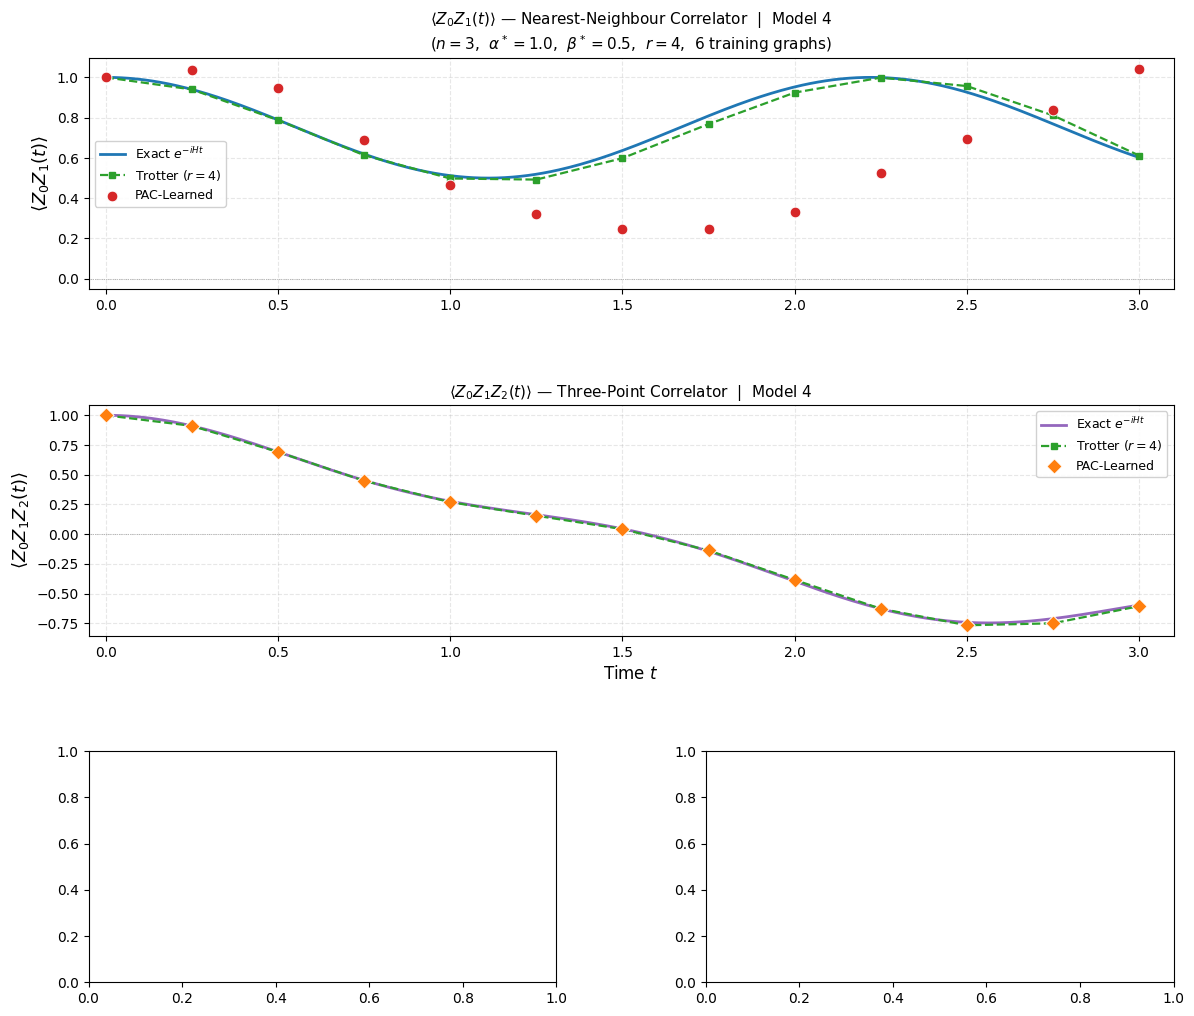

Figure saved.


In [13]:
CLR_EXACT   = '#1f77b4'
CLR_TROTTER = '#2ca02c'
CLR_PAC_ZZ  = '#d62728'
CLR_PAC_ZZZ = '#ff7f0e'
CLR_EX2     = '#9467bd'

# Dense exact curves
t_dense       = np.linspace(0, t_vals[-1], 400)
ex_zz_dense   = [exact_zz(TEST_EDGES,  td) for td in t_dense]
ex_zzz_dense  = [exact_zzz(TEST_EDGES, td) for td in t_dense]

# Feature vectors at selected times (for Z₀Z₁)
t_showcase = [0.5, 1.0, 2.0, 3.0]
# freq_axis  = np.arange(-max_freq, max_freq + 1)
b_showcase = [builder.extract_b_l_full(NUM_QUBITS, TEST_EDGES, ts, R_STEPS, PAULI_ZZ)
              for ts in t_showcase]

fig = plt.figure(figsize=(14, 12))
gs  = gridspec.GridSpec(3, 2, figure=fig, hspace=0.50, wspace=0.32)
ax_zz   = fig.add_subplot(gs[0, :])   # Z₀Z₁ dynamics  (full width)
ax_zzz  = fig.add_subplot(gs[1, :])   # Z₀Z₁Z₂ dynamics (full width)
ax_err  = fig.add_subplot(gs[2, 0])   # combined error
ax_feat = fig.add_subplot(gs[2, 1])   # feature vectors

# ── Z₀Z₁ ─────────────────────────────────────────────────────────────────────
ax_zz.plot(t_dense, ex_zz_dense, color=CLR_EXACT, lw=2.0,
           label=r'Exact $e^{-iHt}$')
ax_zz.plot(t_vals, trotter_zz_vals, color=CLR_TROTTER, lw=1.6, ls='--',
           marker='s', ms=4, label=f'Trotter ($r={R_STEPS}$)')
ax_zz.scatter(t_vals, pac_zz_vals, color=CLR_PAC_ZZ, s=60, zorder=5,
              marker='o', edgecolors='white', lw=0.7, label='PAC-Learned')
ax_zz.axhline(0, color='grey', lw=0.5, ls=':')
ax_zz.set_ylabel(r'$\langle Z_0Z_1(t)\rangle$', fontsize=13)
ax_zz.set_title(
    r'$\langle Z_0Z_1(t)\rangle$ — Nearest-Neighbour Correlator  |  Model 4'
    f'\n($n={NUM_QUBITS}$,  $\\alpha^*={TRUE_ALPHA}$,  $\\beta^*={TRUE_BETA}$,  '
    f'$r={R_STEPS}$,  {NUM_TRAIN} training graphs)',
    fontsize=11)
ax_zz.legend(fontsize=9, framealpha=0.9)
ax_zz.set_xlim(-0.05, t_vals[-1]+0.1)
ax_zz.grid(True, alpha=0.3, ls='--')

# ── Z₀Z₁Z₂ ───────────────────────────────────────────────────────────────────
ax_zzz.plot(t_dense, ex_zzz_dense, color=CLR_EX2, lw=2.0,
            label=r'Exact $e^{-iHt}$')
ax_zzz.plot(t_vals, trotter_zzz_vals, color=CLR_TROTTER, lw=1.6, ls='--',
            marker='s', ms=4, label=f'Trotter ($r={R_STEPS}$)')
ax_zzz.scatter(t_vals, pac_zzz_vals, color=CLR_PAC_ZZZ, s=60, zorder=5,
               marker='D', edgecolors='white', lw=0.7, label='PAC-Learned')
ax_zzz.axhline(0, color='grey', lw=0.5, ls=':')
ax_zzz.set_ylabel(r'$\langle Z_0Z_1Z_2(t)\rangle$', fontsize=13)
ax_zzz.set_title(
    r'$\langle Z_0Z_1Z_2(t)\rangle$ — Three-Point Correlator  |  Model 4',
    fontsize=11)
ax_zzz.legend(fontsize=9, framealpha=0.9)
ax_zzz.set_xlim(-0.05, t_vals[-1]+0.1)
ax_zzz.set_xlabel('Time $t$', fontsize=12)
ax_zzz.grid(True, alpha=0.3, ls='--')

# # ── Combined error (log scale) ────────────────────────────────────────────────
# ax_err.semilogy(t_vals, err_tr_zz   + 1e-12, color=CLR_TROTTER, ls='--',
#                 marker='s', ms=4, alpha=0.6, label=r'Trotter — $Z_0Z_1$')
# ax_err.semilogy(t_vals, err_tr_zzz  + 1e-12, color='#17becf', ls=':',
#                 marker='^', ms=4, alpha=0.6, label=r'Trotter — $Z_0Z_1Z_2$')
# ax_err.semilogy(t_vals, err_pac_zz  + 1e-12, color=CLR_PAC_ZZ,
#                 marker='o', ms=5, label=r'PAC — $Z_0Z_1$')
# ax_err.semilogy(t_vals, err_pac_zzz + 1e-12, color=CLR_PAC_ZZZ,
#                 marker='D', ms=5, label=r'PAC — $Z_0Z_1Z_2$')
# ax_err.set_xlabel('Time $t$', fontsize=12)
# ax_err.set_ylabel(r'$|\hat{y}-y_\mathrm{exact}|$', fontsize=12)
# ax_err.set_title('Absolute Error vs Exact (both observables)', fontsize=11)
# ax_err.legend(fontsize=8, framealpha=0.9)
# ax_err.grid(True, alpha=0.3, ls='--')
# ax_err.set_xlim(-0.05, t_vals[-1]+0.1)

# # ── Feature vectors b_l (for Z₀Z₁) ───────────────────────────────────────────
# cmap = plt.cm.plasma
# for k, (ts, b) in enumerate(zip(t_showcase, b_showcase)):
#     c = cmap(k / (len(t_showcase) - 1))
#     for xi, yi in zip(freq_axis, b):
#         ax_feat.vlines(xi, 0, yi, color=c, lw=1.8, alpha=0.85)
#     ax_feat.scatter(freq_axis, b, color=c, s=25, zorder=5)
# ax_feat.axhline(0, color='grey', lw=0.6)
# ax_feat.set_xlabel('Frequency $l$', fontsize=12)
# ax_feat.set_ylabel(r'$\mathrm{Re}(b_l^{Z_0Z_1}(x_\mathrm{test}))$', fontsize=12)
# ax_feat.set_title(r'$A(U,Z_0Z_1)$ feature vector at selected $t$', fontsize=11)
# handles = [Line2D([0],[0], color=cmap(k/(len(t_showcase)-1)),
#                   marker='o', ms=7, label=f'$t={ts}$')
#            for k, ts in enumerate(t_showcase)]
# ax_feat.legend(handles=handles, fontsize=9)
# ax_feat.grid(True, alpha=0.2, ls='--')

# plt.savefig('../results_model4.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure saved.')

## 7 — Quantitative summary

In [ ]:
print('─' * 62)
print(f'  {"Observable":<20}  {"Method":<16}  {"MAE":>7}  {"Max |err|":>10}')
print('─' * 62)
for obs_name, err_tr, err_pac in [
    ('Z₀Z₁ (2-pt)',   err_tr_zz,  err_pac_zz),
    ('Z₀Z₁Z₂ (3-pt)', err_tr_zzz, err_pac_zzz),
]:
    print(f'  {obs_name:<20}  {"Trotter":<16}  {np.mean(err_tr):7.4f}  {np.max(err_tr):10.4f}')
    print(f'  {"":<20}  {"PAC-Learned":<16}  {np.mean(err_pac):7.4f}  {np.max(err_pac):10.4f}')
    print('─' * 62)

print()
print(f'2D Feature matrix properties at t=1.0 (Z₀Z₁):')
B_demo = np.array([builder.extract_b_l_model4(NUM_QUBITS, g, 1.0, R_STEPS, PAULI_ZZ)
                   for g in TRAIN_GRAPHS])
rank   = np.linalg.matrix_rank(B_demo, tol=1e-8)
sv_b   = np.linalg.svd(B_demo, compute_uv=False)
print(f'  Shape  : {B_demo.shape}  ({SPEC_L0}×{SPEC_L1} = {FEATURE_SIZE} 2D modes)')
print(f'  Rank   : {rank}  (effective DOF)')
cond = sv_b[0]/sv_b[rank-1] if rank>0 else float('inf')
print(f'  Cond   : {cond:.0f}')
print(f'  Singular values: {np.round(sv_b[:rank], 4)}')
nz = np.where(np.abs(B_demo).max(axis=0) > 1e-6)[0]
print(f'  Non-zero (l0,l1) entries: {len(nz)} out of {FEATURE_SIZE}')
print()
print('This is a genuine d=2 experiment:')
print(f'  alpha (ZZ) encoded in freq_zz: l0 in [-{2*R_STEPS}, +{2*R_STEPS}]')
print(f'  beta  (X)  encoded in freq_x:  l1 in [-{2*NUM_QUBITS*R_STEPS}, +{2*NUM_QUBITS*R_STEPS}]')
print('  Feature rank is bounded by min(n_train, non-zero 2D modes).')
